In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


In [3]:
analysis = "DEMO"

In [4]:
narrative_normality = pd.read_csv(f'StatisticalTestResults/{analysis}/Narrative-NormalityCheck-noPOV.csv')
narrative_kruskalwallis = pd.read_csv(f'StatisticalTestResults/{analysis}/Narrative-KruskalWallis-noPOV.csv')
narrative_dunntest = pd.read_csv(f'StatisticalTestResults/{analysis}/Narrative-DunnTest-noPOV.csv')

In [5]:
narrative_normality['significant'].value_counts(dropna = False)

significant
True     22
False     8
Name: count, dtype: int64

In [6]:
narrative_kruskalwallis = narrative_kruskalwallis.set_index('feature')
narrative_kruskalwallis

,kruskal_stat,p_value,eta2,significant,p_bh_corrected,alpha
feature,,,,,,
childhood_abuse,129.354,8.150505e-29,0.0258,True,2.037626e-28,0.005
adult_victim,229.912,1.189135e-50,0.0462,True,1.189135e-49,0.005
victim_female,38.152,5.192001e-09,0.0073,True,5.768890e-09,0.005
victim_male,29.444,4.039678e-07,0.0056,True,4.039678e-07,0.005
perpetrator_female,134.989,4.869087e-30,0.0270,True,2.434543e-29,0.005
perpetrator_male,130.630,4.305173e-29,0.0261,True,1.435058e-28,0.005
stranger_assault,85.179,3.187927e-19,0.0169,True,6.375854e-19,0.005
acquaintance_assault,42.248,6.698664e-10,0.0082,True,8.373330e-10,0.005
family_member,78.494,9.020300e-18,0.0155,True,1.503383e-17,0.005


In [7]:
print(np.round(narrative_normality['alpha'].unique()*10**3, 2),
np.round(narrative_kruskalwallis['alpha'].unique()*10**2, 2),
np.round(narrative_dunntest['alpha'].unique()*10**3, 2))

[1.67] [0.5] [1.67]


In [8]:
comp_order  = ['entailment vs neutral', 'entailment vs contradiction', 'neutral vs contradiction']
comp_names  = ['ENT*NEU', 'ENT*CON', 'NEU*CON']
myth_order  = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']
myth_names  = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']

In [14]:
if analysis == 'MYTHS':
    order = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']
    names = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
else:
    order = ['childhood_abuse', 'adult_victim', 'victim_female', 'victim_male',
       'perpetrator_female', 'perpetrator_male', 
             # 'first_person_victim', 'third_person_victim', 'first_person_perpetrator', 'third_person_perpetrator', 
             'stranger_assault', 'acquaintance_assault', 'family_member', 'intimate_partner']
    names = ['Minor', 'Adult', 'Vic-F', 'Vic-M', 'Perp-F', 'Perp-M', 
               # 'Vic-1st', 'Vic-3rd', 'Perp-1st', 'Perp-3rd', 
             'Stranger', 'Acquaint', 'FamilyM', 'IntimateP']

/tmp/ipykernel_1950133/2333770199.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


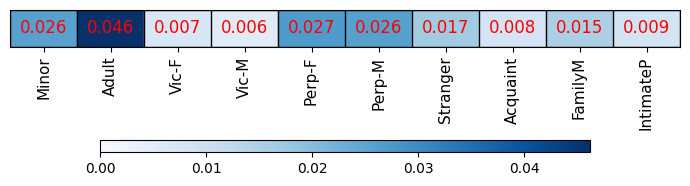

In [30]:
# ── Kruskal-Wallis ─────────────────────────────────────────────────────────────

vmin, vmax = 0, narrative_kruskalwallis['eta2'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Blues

fig, ax = plt.subplots(figsize=(7, 1.5))
ax.set_ylim(0, 1)
ax.set_xlim(0, len(order))
ax.set_xticks(np.arange(len(order)) + 0.5)
ax.set_xticklabels(names, rotation=90, ha='center', fontsize=11)
ax.set_yticks([])

for c, feat in enumerate(order):
    color = cmap(norm(narrative_kruskalwallis.loc[feat, 'eta2'])) if narrative_kruskalwallis.loc[feat, 'significant'] else '#4A4A4A'
    ax.add_patch(patches.Rectangle((c, 0), 1, 1, color=color))
    ax.text(c + 0.5, 0.5, f"{narrative_kruskalwallis.loc[feat, 'eta2']:.3f}",
            color='red', fontsize=12, ha='center', va='center')

for c in range(len(order) + 1):
    ax.axvline(c, color='black', linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(1, color='black', linewidth=1)

cbar_ax = fig.add_axes([0.15, -0.05, 0.7, 0.08])
fig.colorbar(ScalarMappable(cmap=cmap, norm=norm), cax=cbar_ax, orientation='horizontal')
plt.tight_layout()
plt.savefig(f'Figures/{analysis}/Narr-Kruskal-noPOV.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

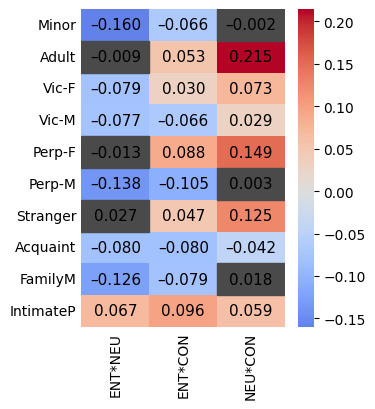

In [36]:
# ── Dunn Test ──────────────────────────────────────────────────────────────────
dunn_pivot = narrative_dunntest.pivot(index='feature', columns='pair', values='rank_biserial').loc[order, comp_order]
sig_pivot  = narrative_dunntest.pivot(index='feature', columns='pair', values='significant').loc[order, comp_order]

fig, ax = plt.subplots(figsize=(3.8, 4.2))
sns.heatmap(dunn_pivot, annot=True, cmap='coolwarm', center=0, ax=ax,
            annot_kws={"color": "black", "size": 11}, linecolor='black', fmt=".3f", cbar=True)
ax.tick_params(axis='both', which='both', length=0)

# for i in range(dunn_pivot.shape[0]):
#     for j in range(dunn_pivot.shape[1]):
#         if not sig_pivot.iloc[i, j]:
#             ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=1, zorder=2))
for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if not sig.iloc[i]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=1, zorder=2))

for text in ax.texts:
    val = text.get_text()
    if val.startswith('−') or val.startswith('-'):
        text.set_text('–' + val.lstrip('−').lstrip('-'))

ax.set_yticklabels(names, rotation=0)
ax.set_xticklabels(comp_names, rotation=90, ha='center')
ax.set_xlabel(None)
ax.set_ylabel(None)

plt.tight_layout()
plt.savefig(F'Figures/{analysis}/Narr-Dunn-noPOV.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

In [62]:
df = pd.read_csv('ProjectionValidation/NarrativeProjections-withDemographics.csv')
feat = 'victim_intoxication'
for label in ['entailment', 'neutral', 'contradiction']:
    vals = df.loc[df[feat] == label, 'projection_sbert']
    print(f"{label}: median={vals.median():.4f} mean={vals.mean():.4f}")

entailment: median=-0.1011 mean=-0.0983
neutral: median=-0.1217 mean=-0.1167
contradiction: median=-0.1086 mean=-0.1028
